# Spider Diagrams

Spider diagrams show multi-element geochemical patterns. Concentrations are commonly normalized to a reference composition, such as C1 chondrite, Primitive Mantle, or N-MORB, and plotted on a logarithmic y-axis.

This notebook shows:

1. high-level spider diagrams with `spider()`;
2. normalized values with `spider_norm()`;
3. NumPy-style input;
4. manual/custom spider plots with `spiderplot()`.

## Import Libraries and Load the Dataset

The spider plotting tools are available from `geochem.plt`. The example dataset is loaded and preprocessed before plotting.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geochem.plt as gc
from geochem.parameters import getvalues_SM89


In [2]:
DOCS_DIR = Path.cwd()
if not (DOCS_DIR / "data_example.csv").exists():
    DOCS_DIR = Path.cwd() / "docs"

csv_file = DOCS_DIR / "data_example.csv"
df = pd.read_csv(csv_file)

gc.preproc(df)
df.head()

Strip whitespaces from column names
>  column names before:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2 ', 'Al2O3 ', 'TiO2 ', 'FeO', 'Fe2O3 ', 'FeOT', 'CaO ', 'MgO', 'MnO ', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']
>  column names after:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2', 'Al2O3', 'TiO2', 'FeO', 'Fe2O3', 'FeOT', 'CaO', 'MgO', 'MnO', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']

Ensuring geochemical data columns are numeric
>  Processed/verified numeric columns: Cr (parsed)

Check columns with Fe oxides and calculate FeOT
.. FeO column in database
.. Fe2

,Sample,Type,Description,Reference,Source,SiO2,Al2O3,TiO2,FeO,Fe2O3,...,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu
0,HOR-06-01,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.55,17.42,0.81,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CLHE1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.35,17.76,0.83,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CLHE2,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.08,17.02,0.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CLHE-TF-04,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,51.51,13.99,0.64,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLHW1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.73,17.91,0.88,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 53 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sample       129 non-null    str    
 1   Type         129 non-null    str    
 2   Description  129 non-null    str    
 3   Reference    129 non-null    str    
 4   Source       129 non-null    str    
 5   SiO2         129 non-null    float64
 6   Al2O3        129 non-null    float64
 7   TiO2         129 non-null    float64
 8   FeO          0 non-null      float64
 9   Fe2O3        31 non-null     float64
 10  FeOT         129 non-null    float64
 11  CaO          129 non-null    float64
 12  MgO          129 non-null    float64
 13  MnO          129 non-null    float64
 14  Na2O         129 non-null    float64
 15  K2O          129 non-null    float64
 16  P2O5         129 non-null    float64
 17  LOI          0 non-null      float64
 18  Sum          129 non-null    float64
 19  Cu           121 no

## Choose Elements to Plot

`geochem` provides a default trace-element order commonly used for spider diagrams.

In [4]:
trace = gc.getnames_trace()
well_measured_trace = ["Rb", "Ba", "Th", "Nb", "La", "Ce", "Sr", "Nd", "Zr"]

trace

['Cs',
 'Rb',
 'Ba',
 'Th',
 'U',
 'Nb',
 'K',
 'La',
 'Ce',
 'Pb',
 'Pr',
 'Sr',
 'P',
 'Nd',
 'Zr',
 'Sm',
 'Eu',
 'Ti',
 'Dy',
 'Y',
 'Yb',
 'Lu']

## High-Level Spider Diagram

The high-level `spider()` function normalizes the data and plots the diagram in one step.

The available built-in normalization options are:

- `chondrite`: C1 chondrite;
- `mantle`: Primitive Mantle;
- `nmorb`: N-type MORB.

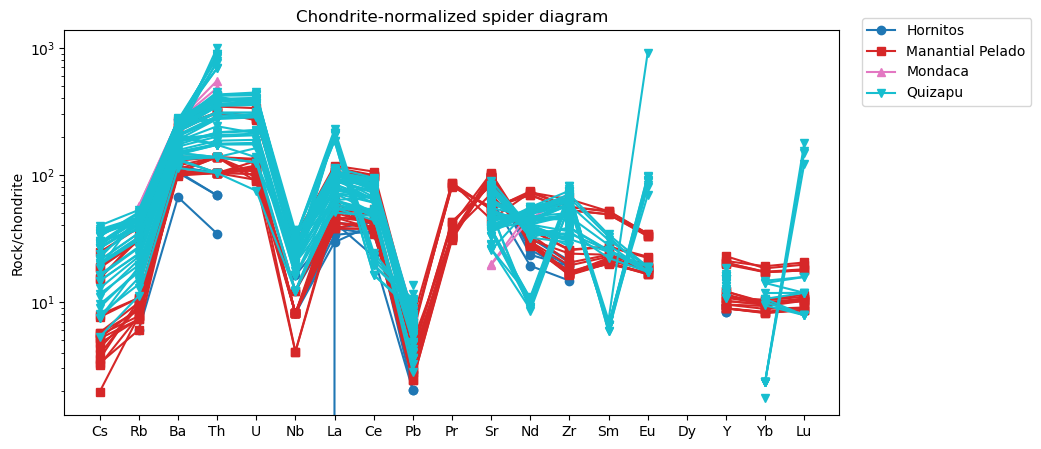

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
gc.spider(
    df,
    elements=trace,
    norm="chondrite",
    fmt={"groupby": "Source", "title": "Chondrite-normalized spider diagram", "show": False},
    opt={"dropna": False},
    ax=ax,
)
plt.show()

Rows with missing values can be removed with `opt={"dropna": True}`. This gives cleaner lines, but it can remove many samples when some elements are sparsely measured. For that reason, use a well-measured subset of elements when dropping missing rows.

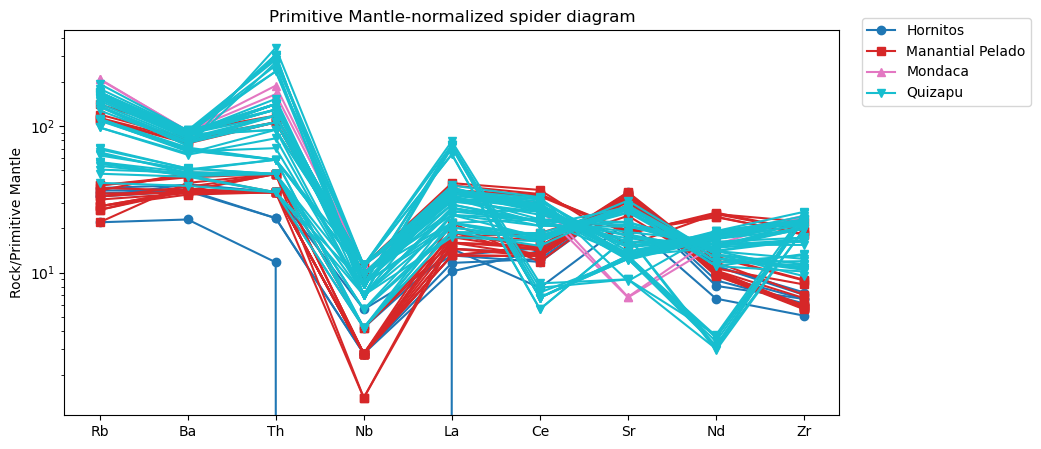

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
gc.spider(
    df,
    elements=well_measured_trace,
    norm="mantle",
    fmt={"groupby": "Source", "title": "Primitive Mantle-normalized spider diagram", "show": False},
    opt={"dropna": True},
    ax=ax,
)
plt.show()

## Normalization Values

The reference values come from Sun and McDonough (1989) and are available through `getvalues_SM89()`.

In [7]:
values = getvalues_SM89("chondrite")
{k: values[k] for k in ["Source", "Rb", "Ba", "La", "Ce", "Sr", "Y", "Yb"]}

{'Source': 'C1 chondrite',
 'Rb': 2.32,
 'Ba': 2.41,
 'La': 0.237,
 'Ce': 0.612,
 'Sr': 7.26,
 'Y': 1.57,
 'Yb': 0.17}

## Calculate Normalized Data

Use `spider_norm()` when you want the normalized values before plotting. This is useful for checking data quality, identifying missing elements, or building custom diagrams.

In [8]:
df_norm = gc.spider_norm(df, elements=trace, values=values)
norm_elements = list(df_norm.columns)
df_norm["Sample"] = df["Sample"]
df_norm["Source"] = df["Source"]

df_norm.head()

,Cs,Rb,Ba,Th,U,Nb,La,Ce,Pb,Pr,...,Nd,Zr,Sm,Eu,Dy,Y,Yb,Lu,Sample,Source
0,NaN,9.051724,104.149378,68.965517,NaN,8.130081,33.755274,35.947712,2.834008,NaN,...,25.695931,17.829457,NaN,NaN,NaN,9.554140,NaN,NaN,HOR-06-01,Hornitos
1,NaN,9.482759,106.224066,68.965517,NaN,8.130081,37.974684,34.313725,4.048583,NaN,...,27.837259,19.121447,NaN,NaN,NaN,8.917197,NaN,NaN,CLHE1,Hornitos
2,NaN,9.913793,107.053942,103.448276,NaN,12.195122,42.194093,39.215686,4.453441,NaN,...,23.554604,19.121447,NaN,NaN,NaN,8.280255,NaN,NaN,CLHE2,Hornitos
3,NaN,6.034483,66.804979,34.482759,NaN,0.000000,42.194093,22.875817,2.024291,NaN,...,19.271949,14.728682,NaN,NaN,NaN,8.280255,NaN,NaN,CLHE-TF-04,Hornitos
4,NaN,9.051724,116.182573,103.448276,NaN,8.130081,29.535865,40.849673,2.024291,NaN,...,32.119914,20.413437,NaN,NaN,NaN,8.917197,NaN,NaN,CLHW1,Hornitos


In [9]:
df_norm[norm_elements].describe()

,Cs,Rb,Ba,Th,U,Nb,La,Ce,Pb,Pr,Sr,Nd,Zr,Sm,Eu,Dy,Y,Yb,Lu
count,63.000000,107.000000,123.000000,107.000000,53.000000,123.000000,82.000000,82.000000,98.000000,19.000000,123.000000,82.000000,123.000000,38.000000,37.000000,0.0,63.000000,38.000000,32.000000
mean,18.912530,31.124919,203.129339,315.446342,244.622642,23.180977,92.466811,58.823529,6.106626,47.689751,57.505622,39.019429,51.203882,23.111455,59.473439,NaN,13.547670,9.142415,29.183071
std,11.183963,14.962112,59.348085,206.270038,117.521117,8.595488,50.075070,24.451233,2.296569,22.591682,22.516795,15.940407,19.174045,13.730230,147.090468,NaN,3.445661,5.070782,47.284902
min,1.968085,6.034483,66.804979,34.482759,75.000000,0.000000,29.535865,16.339869,2.024291,30.842105,19.696970,8.565310,14.728682,5.882353,16.551724,NaN,8.280255,1.764706,7.874016
25%,7.765957,16.379310,147.510373,137.931034,125.000000,18.821138,54.852321,39.624183,4.096154,32.526316,38.016529,29.111349,36.563307,10.359477,17.241379,NaN,10.828025,3.808824,9.055118
50%,18.936170,34.879310,221.576763,310.344828,226.250000,24.390244,88.607595,57.189542,6.072874,34.000000,52.066116,40.685225,56.072351,22.222222,18.965517,NaN,14.012739,9.617647,10.826772
75%,28.670213,44.612069,256.016598,413.793103,362.500000,28.617886,105.485232,80.065359,7.287449,61.947368,78.305785,49.250535,66.954780,27.287582,34.482759,NaN,15.286624,10.588235,17.716535
max,39.893617,57.327586,278.838174,1000.000000,445.000000,36.585366,227.848101,106.209150,13.655870,86.631579,102.892562,74.389722,82.359173,52.156863,913.793103,NaN,22.929936,19.117647,177.165354


## NumPy-Style Input

`spider_norm()` and `spiderplot()` also work with NumPy arrays. In this mode, the number of array columns must match the number of element names.

In [10]:
selected_elements = ["Rb", "Ba", "La", "Ce", "Sr", "Nd", "Zr", "Y", "Yb"]
array_data = df[selected_elements].head(5).to_numpy(dtype=float)

array_norm = gc.spider_norm(
    array_data,
    elements=selected_elements,
    values=getvalues_SM89("chondrite"),
)

array_norm

array([[  9.05172414, 104.14937759,  33.75527426,  35.94771242,
         92.01101928,  25.69593148,  17.82945736,   9.55414013,
                 nan],
       [  9.48275862, 106.22406639,  37.97468354,  34.31372549,
         93.66391185,  27.8372591 ,  19.12144703,   8.91719745,
                 nan],
       [  9.9137931 , 107.05394191,  42.19409283,  39.21568627,
         91.32231405,  23.55460385,  19.12144703,   8.28025478,
                 nan],
       [  6.03448276,  66.80497925,  42.19409283,  22.87581699,
         64.46280992,  19.27194861,  14.72868217,   8.28025478,
                 nan],
       [  9.05172414, 116.18257261,  29.53586498,  40.8496732 ,
        102.3415978 ,  32.11991435,  20.41343669,   8.91719745,
                 nan]])

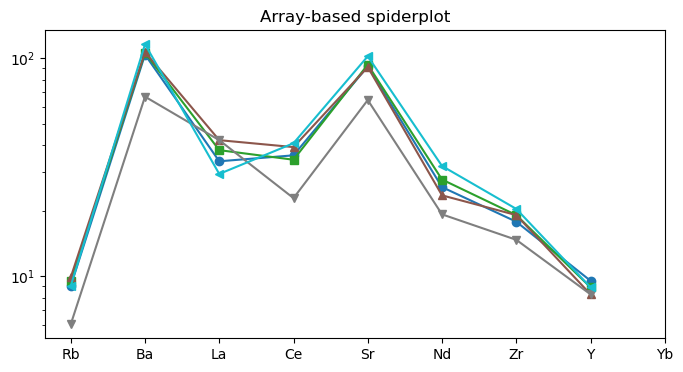

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
gc.spiderplot(
    array_norm,
    elements=selected_elements,
    fmt={"title": "Array-based spiderplot", "show": False},
    opt={"dropna": False},
    ax=ax,
)
plt.show()

## Custom Spider Diagram

For custom figures, first normalize the data with `spider_norm()`, then call `spiderplot()` on selected subsets. The full REE list includes `Dy` and `Ho`, which have no values in this example dataset, so the manual example uses the measured REE subset.

In [12]:
ree = ["La", "Ce", "Nd", "Sm", "Eu", "Gd", "Tb", "Tm", "Yb", "Lu"]
ree_values = getvalues_SM89("chondrite")
ree_norm = gc.spider_norm(df, elements=ree, values=ree_values)
ree_norm["Source"] = df["Source"]

ree_norm.head()

,La,Ce,Nd,Sm,Eu,Gd,Tb,Tm,Yb,Lu,Source
0,33.755274,35.947712,25.695931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hornitos
1,37.974684,34.313725,27.837259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hornitos
2,42.194093,39.215686,23.554604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hornitos
3,42.194093,22.875817,19.271949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hornitos
4,29.535865,40.849673,32.119914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hornitos


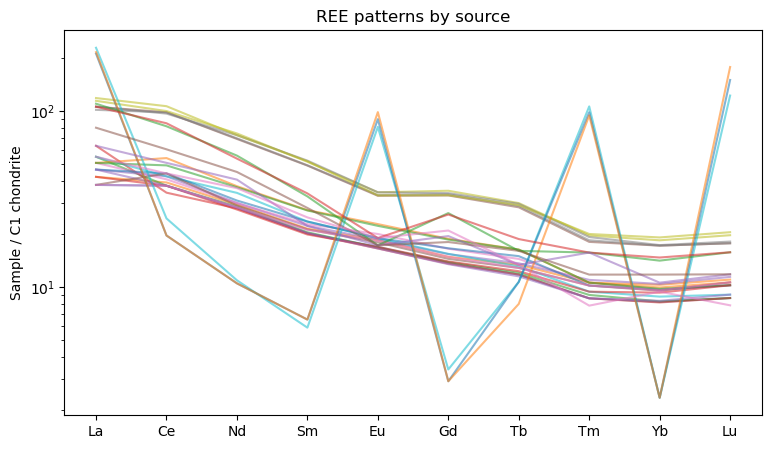

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

for source, group in ree_norm.groupby("Source"):
    gc.spiderplot(
        group,
        elements=ree,
        fmt={"fmt_plt": {"marker": "", "linestyle": "-", "alpha": 0.55}, "label": source, "show": False},
        opt={"dropna": True},
        ax=ax,
    )

ax.set_ylabel("Sample / C1 chondrite")
ax.set_title("REE patterns by source")
plt.show()

## Compare Two Groups

Manual plotting also makes it easy to compare selected groups with different styles.

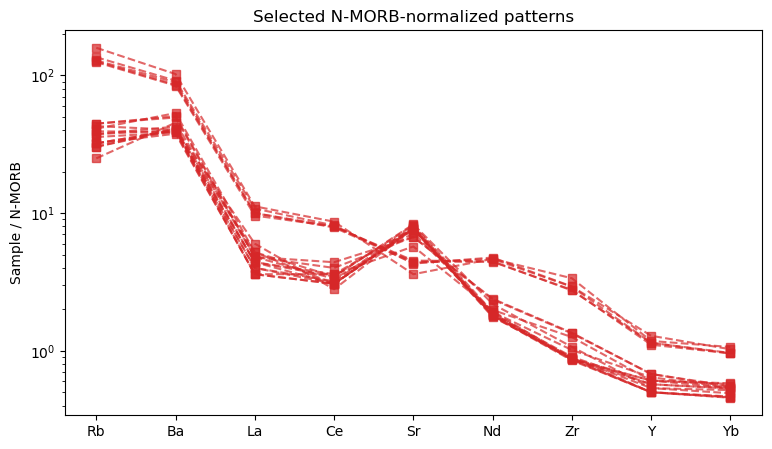

In [14]:
nmorb_values = getvalues_SM89("nmorb")
subset_elements = ["Rb", "Ba", "La", "Ce", "Sr", "Nd", "Zr", "Y", "Yb"]
subset_norm = gc.spider_norm(df, elements=subset_elements, values=nmorb_values)
subset_norm["Source"] = df["Source"]

fig, ax = plt.subplots(figsize=(9, 5))

for source, style in {
    "Hornitos": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
    "Manantial Pelado": {"color": "tab:red", "linestyle": "--", "marker": "s"},
}.items():
    group = subset_norm[subset_norm["Source"] == source]
    gc.spiderplot(
        group,
        elements=subset_elements,
        fmt={"fmt_plt": {**style, "alpha": 0.7}, "label": source, "show": False},
        opt={"dropna": True},
        ax=ax,
    )

ax.set_ylabel("Sample / N-MORB")
ax.set_title("Selected N-MORB-normalized patterns")
plt.show()

## Summary

Use `gc.spider()` for quick normalized spider diagrams. Use `gc.spider_norm()` and `gc.spiderplot()` when you want to inspect normalized values or build customized multi-element figures.